# 40.12 Межканальное влияние реокардиомонитора РНЦХ

## Задача

В техническом тесте кабели поочерёдно отключались от прибора без отклеивания
электродов. Последовательность состояний восстановлена как
`оба → только канал 2 → оба → только канал 1 → оба` и проверяется по `BASE`.

Состояние с одним каналом сравнивается с линейно интерполированным уровнем двух
соседних сегментов `оба`. Это частично учитывает медленное изменение во
времени, но не делает последовательные фрагменты одновременными.

Произвольная нормировка технических сегментов по фазе удалена: они не являются
сердечными циклами, а ЭКГ-разметка этой записи непригодна для пульсового
ансамблирования.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from ttrkg_analysis import robust_signal_metrics

REAL_MODE = os.environ.get("KALMYKOV_RUN_REAL", "0") == "1"
EXPLORATORY_MODE = os.environ.get("KALMYKOV_RUN_EXPLORATORY", "0") == "1"


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def discover_json(directory, predicate):
    matches = []
    for path in sorted(Path(directory).glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        if predicate(item):
            matches.append((path, item))
    if len(matches) != 1:
        raise RuntimeError(f"Ожидался один подходящий JSON, найдено {len(matches)}")
    return matches[0]


test = robust_signal_metrics([0.0, 0.0, 1.0, 2.0, 2.0])
assert test["fraction_at_exact_extremes"] == 0.8
print("40.12 synthetic_self_test: passed")


40.12 synthetic_self_test: passed


In [2]:
if not REAL_MODE:
    print("40.12: реальный расчёт не запущен")
else:
    if not EXPLORATORY_MODE:
        raise RuntimeError("Разметка состояний каналов пока кандидатная; запускайте только исследовательский режим")
    config_path = Path(os.environ["KALMYKOV_EXP03_CONFIG"]).expanduser().resolve()
    config = json.loads(config_path.read_text(encoding="utf-8"))
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    qc_dir = derived_root / "exp03" / "qc"
    record_manifest_path, record_manifest = discover_json(qc_dir, lambda item: item.get("experiment_id") == "exp03" and item.get("records") and "include" in item["records"][0] and sum(row.get("include") is True for row in item["records"]) == 4)
    diagnostic_path, diagnostic = discover_json(qc_dir, lambda item: item.get("records") and "channel_state_segments_s" in item["records"][0])
    included = {row["record_id"]: row for row in record_manifest["records"] if row.get("include") is True}
    switch_specs = [row for row in config["recordings"] if row.get("role") == "channel_switch_test"]
    if len(switch_specs) != 1 or switch_specs[0]["record_id"] not in included:
        raise RuntimeError("Не найдена единственная основная запись переключения каналов")
    record = included[switch_specs[0]["record_id"]]
    diagnostic_rows = [row for row in diagnostic["records"] if row.get("record_id") == record["record_id"]]
    if len(diagnostic_rows) != 1 or diagnostic_rows[0].get("input_sha256") != record["input_sha256"]:
        raise RuntimeError("Кандидатные интервалы относятся к другой версии записи")
    segments = diagnostic_rows[0]["channel_state_segments_s"]
    expected_sequence = ["both", "ch2", "both", "ch1", "both"]
    if [segment["state"] for segment in segments] != expected_sequence:
        raise RuntimeError("Последовательность состояний не совпала с протоколом")

    data_root = Path(config["data_root"]).expanduser().resolve()
    csv_root = (data_root / config["csv_subdir"]).resolve()
    source = (data_root / record["relative_path"]).resolve()
    source.relative_to(csv_root)
    if sha256_file(source) != record["input_sha256"]:
        raise RuntimeError("Исходный CSV изменился после QC")
    frame = pd.read_csv(source)
    if list(frame.columns) != config["source_columns"]:
        raise RuntimeError("Схема CSV не совпала")
    frame.columns = ["time_s", "rheo_1_mohm", "base_1_ohm", "qs_1_ohm", "ecg_v", "rheo_2_mohm", "base_2_ohm", "qs_2_ohm"]
    time_s = frame["time_s"].to_numpy(float)
    threshold = float(config["active_channel_threshold_ohm"])
    edge_margin_s = 0.5
    segment_rows, summaries = [], []
    state_channels = {"both": (1, 2), "ch1": (1,), "ch2": (2,)}
    for index, segment in enumerate(segments, start=1):
        left, right = float(segment["start_s"]) + edge_margin_s, float(segment["end_s"]) - edge_margin_s
        mask = (time_s >= left) & (time_s <= right)
        if mask.sum() < 10:
            raise RuntimeError("После удаления переходных краёв сегмент слишком короток")
        observed_active = []
        if np.mean(frame.loc[mask, "base_1_ohm"].to_numpy(float) > threshold) > 0.95:
            observed_active.append(1)
        if np.mean(frame.loc[mask, "base_2_ohm"].to_numpy(float) > threshold) > 0.95:
            observed_active.append(2)
        if tuple(observed_active) != state_channels[segment["state"]]:
            raise RuntimeError("Кандидатное состояние не подтверждено порогом BASE")
        row = {"segment": index, "state": segment["state"], "start_s": left, "end_s": right, "center_s": 0.5 * (left + right), "duration_s": right - left}
        for channel in (1, 2):
            base_metrics = robust_signal_metrics(frame.loc[mask, f"base_{channel}_ohm"].to_numpy(float))
            rheo_metrics = robust_signal_metrics(frame.loc[mask, f"rheo_{channel}_mohm"].to_numpy(float))
            row[f"base{channel}_median_ohm"] = base_metrics["median"]
            row[f"base{channel}_mad_ohm"] = base_metrics["mad"]
            row[f"rheo{channel}_robust_range_mohm"] = rheo_metrics["robust_range"]
            row[f"rheo{channel}_extreme_fraction"] = rheo_metrics["fraction_at_exact_extremes"]
        summaries.append(row)
        segment_rows.append({"сегмент": index, "состояние": segment["state"], "длительность_с": right - left, "BASE1_медиана_Ом": row["base1_median_ohm"], "BASE2_медиана_Ом": row["base2_median_ohm"], "RHEO1_робастный_размах_мОм": row["rheo1_robust_range_mohm"], "RHEO2_робастный_размах_мОм": row["rheo2_robust_range_mohm"], "доля_крайних_RHEO1": row["rheo1_extreme_fraction"], "доля_крайних_RHEO2": row["rheo2_extreme_fraction"]})

    def interpolated_both_reference(target_index, channel, field):
        target = summaries[target_index]
        before = max((row for row in summaries[:target_index] if row["state"] == "both"), key=lambda row: row["center_s"])
        after = min((row for row in summaries[target_index + 1:] if row["state"] == "both"), key=lambda row: row["center_s"])
        weight = (target["center_s"] - before["center_s"]) / (after["center_s"] - before["center_s"])
        key = field.format(channel=channel)
        reference = (1.0 - weight) * before[key] + weight * after[key]
        return reference, before[key], after[key]

    comparisons = []
    for target_state, channel, disconnected in (("ch1", 1, 2), ("ch2", 2, 1)):
        target_index = next(i for i, row in enumerate(summaries) if row["state"] == target_state)
        target = summaries[target_index]
        item = {"observed_channel": channel, "disconnected_channel": disconnected, "isolated_state": target_state}
        for label, field in (("baseline", "base{channel}_median_ohm"), ("rheo_robust_range", "rheo{channel}_robust_range_mohm")):
            reference, before, after = interpolated_both_reference(target_index, channel, field)
            value = target[field.format(channel=channel)]
            item[label] = {"isolated": value, "interpolated_both_reference": reference, "difference_isolated_minus_both": value - reference, "ratio_isolated_to_both": None if reference == 0.0 else value / reference, "bracketing_both_change": after - before}
        comparisons.append(item)

    artifact = {"schema_version": 3, "analysis": "40.12_interchannel_effect", "status": "exploratory_hypothesis_not_validated", "fact_status": "channel_state_change_observed_without_electrode_repositioning", "magnitude_status": "preliminary_sequential_within_record_comparison", "cause": "not_investigated", "state_source": "candidate_intervals_cross_checked_by_BASE_threshold", "edge_margin_s": edge_margin_s, "segments": summaries, "comparisons": comparisons, "input_sha256": record["input_sha256"], "record_manifest_sha256": sha256_file(record_manifest_path), "diagnostic_manifest_sha256": sha256_file(diagnostic_path)}
    out_dir = derived_root / "exp03" / "exploratory"
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "40.12_interchannel_effect.exploratory.json").write_text(json.dumps(artifact, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    segment_table = pd.DataFrame(segment_rows)
    comparison_table = pd.DataFrame([{"наблюдаемый_канал": item["observed_channel"], "отключённый_канал": item["disconnected_channel"], "BASE_разность_Ом": item["baseline"]["difference_isolated_minus_both"], "BASE_отношение": item["baseline"]["ratio_isolated_to_both"], "RHEO_разность_размахов_мОм": item["rheo_robust_range"]["difference_isolated_minus_both"], "RHEO_отношение_размахов": item["rheo_robust_range"]["ratio_isolated_to_both"], "изменение_BASE_между_опорными_both_Ом": item["baseline"]["bracketing_both_change"]} for item in comparisons])
    segment_table.to_csv(out_dir / "40.12_segment_metrics.exploratory.csv", index=False, encoding="utf-8-sig")
    comparison_table.to_csv(out_dir / "40.12_comparisons.exploratory.csv", index=False, encoding="utf-8-sig")
    print("40.12: количественно описаны оба направления переключения; механизм не назначен")
    display(segment_table.round(4))
    display(comparison_table.round(4))


40.12: количественно описаны оба направления переключения; механизм не назначен


,сегмент,состояние,длительность_с,BASE1_медиана_Ом,BASE2_медиана_Ом,RHEO1_робастный_размах_мОм,RHEO2_робастный_размах_мОм,доля_крайних_RHEO1,доля_крайних_RHEO2
0,1,both,11.075,54.1605,40.868,906.0753,455.5840,0.0027,0.0009
1,2,ch2,9.910,0.0000,36.873,492.8009,564.6344,0.0010,0.0010
2,3,both,10.030,54.1920,40.939,978.6028,675.5752,0.0648,0.0648
3,4,ch1,7.775,92.7130,0.000,560.6213,1209.8860,0.0013,0.1530
4,5,both,2.210,54.0950,33.364,653.3226,1011.4316,0.0045,0.0451


,наблюдаемый_канал,отключённый_канал,BASE_разность_Ом,BASE_отношение,RHEO_разность_размахов_мОм,RHEO_отношение_размахов,изменение_BASE_между_опорными_both_Ом
0,1,2,38.5814,1.7127,-215.3588,0.7225,-0.097
1,2,1,-4.0313,0.9014,-3.5026,0.9938,0.071


In [3]:
if REAL_MODE:
    interpretation_rows = []
    for item in comparisons:
        base = item["baseline"]
        rheo = item["rheo_robust_range"]
        base_percent = 100.0 * (base["ratio_isolated_to_both"] - 1.0)
        base_to_bracket = abs(base["difference_isolated_minus_both"]) / max(abs(base["bracketing_both_change"]), np.finfo(float).eps)
        rheo_exceeds_bracket = abs(rheo["difference_isolated_minus_both"]) > abs(rheo["bracketing_both_change"])
        interpretation_rows.append({
            "наблюдаемый_канал": item["observed_channel"],
            "отключённый_канал": item["disconnected_channel"],
            "изменение_BASE_%": base_percent,
            "BASE_эффект_к_изменению_между_both": base_to_bracket,
            "изменение_RHEO_размаха_превышает_опорное": rheo_exceeds_bracket,
            "вывод": "BASE меняется существенно; причина неизвестна. RHEO-размах по одной последовательности не отделён от временной изменчивости."
        })
    display(pd.DataFrame(interpretation_rows).round(3))


,наблюдаемый_канал,отключённый_канал,изменение_BASE_%,BASE_эффект_к_изменению_между_both,изменение_RHEO_размаха_превышает_опорное,вывод
0,1,2,71.273,397.747,False,BASE меняется существенно; причина неизвестна....
1,2,1,-9.855,56.779,False,BASE меняется существенно; причина неизвестна....


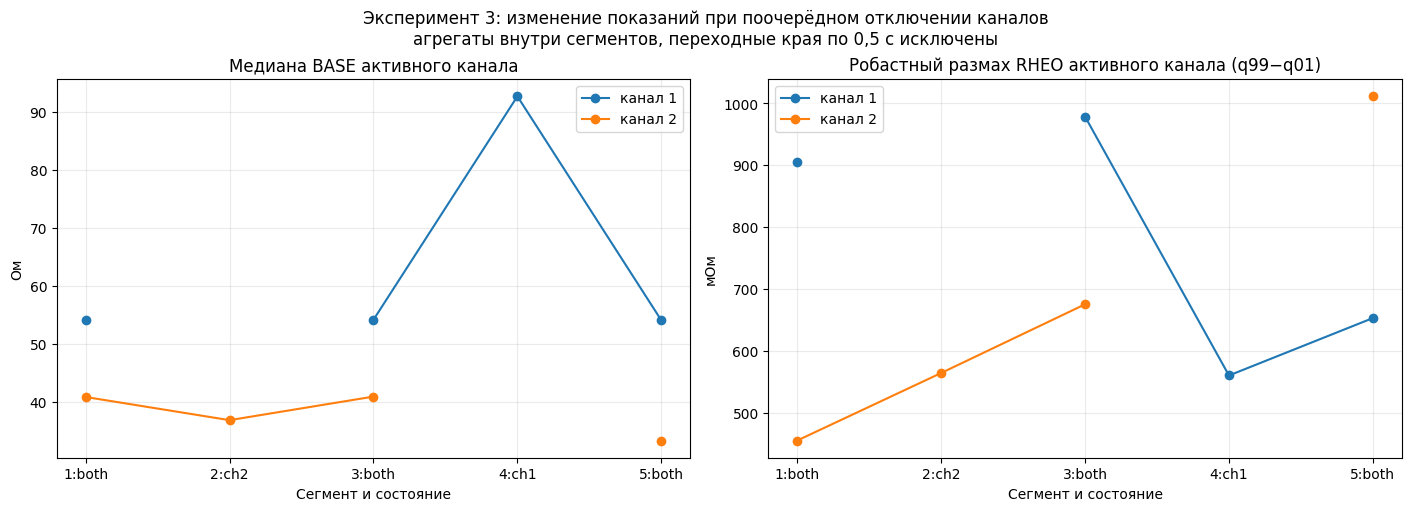

In [4]:
if REAL_MODE:
    labels = [f"{row['segment']}:{row['state']}" for row in summaries]
    x = np.arange(len(summaries))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for channel, color in ((1, "tab:blue"), (2, "tab:orange")):
        base_values = [row[f"base{channel}_median_ohm"] if channel in state_channels[row["state"]] else np.nan for row in summaries]
        rheo_values = [row[f"rheo{channel}_robust_range_mohm"] if channel in state_channels[row["state"]] else np.nan for row in summaries]
        axes[0].plot(x, base_values, "o-", color=color, label=f"канал {channel}")
        axes[1].plot(x, rheo_values, "o-", color=color, label=f"канал {channel}")
    axes[0].set(title="Медиана BASE активного канала", ylabel="Ом", xticks=x, xticklabels=labels)
    axes[1].set(title="Робастный размах RHEO активного канала (q99−q01)", ylabel="мОм", xticks=x, xticklabels=labels)
    for axis in axes:
        axis.set_xlabel("Сегмент и состояние")
        axis.grid(alpha=0.25)
        axis.legend()
    fig.suptitle("Эксперимент 3: изменение показаний при поочерёдном отключении каналов\nагрегаты внутри сегментов, переходные края по 0,5 с исключены")
    fig.savefig(out_dir / "40.12_interchannel_effect_aggregates.png", dpi=160)
    plt.show()


## Интерпретация и ограничения

- Изменение показаний при отключении соседнего канала — подтверждённое
  экспериментальное наблюдение для этой ревизии прибора.
- Численная величина эффекта предварительная: интервалы имеют статус
  `pending_manual_review`, сравнение последовательное, независимых повторов
  режима с одним каналом нет.
- Робастный размах `q99−q01` описывает изменчивость записанного `RHEO`, но без
  надёжной ЭКГ-разметки не называется пульсовой амплитудой.
- Причина эффекта не исследована; конкретные механизмы остаются гипотезами.
